FASTFLOW SPEEDUP/EFFICIENCY


ok


non è un triangolo valido


Speedup and Efficiency Calculated:
Size 32: Speedup = [0.014130793427333319, 0.015043686171470857, 0.00968053044002411, 0.0036487975553510773, 0.002205271505173325], Efficiency = [0.014130793427333319, 0.007521843085735429, 0.0024201326100060276, 0.00045609969441888466, 0.0001378294690733328]
Size 1024: Speedup = [0.24156850499534152, 0.24468452672562718, 0.21822630569527976, 0.07814786957786843, 0.045573997233748276], Efficiency = [0.24156850499534152, 0.12234226336281359, 0.05455657642381994, 0.009768483697233554, 0.0028483748271092672]
Size 16384: Speedup = [0.7949046150182509, 0.7689480788265995, 1.415181706169928, 1.0047360153508977, 0.5898807995294937], Efficiency = [0.7949046150182509, 0.3844740394132998, 0.353795426542482, 0.12559200191886222, 0.036867549970593355]
Size 262144: Speedup = [0.90828997863586, 0.9067272588142073, 2.1845587491896974, 3.3280813974558763, 3.6299645232377737], Efficiency = [0.90828997863586, 0.4533636294071037, 0.5461396872974243, 0.41601017468198453, 

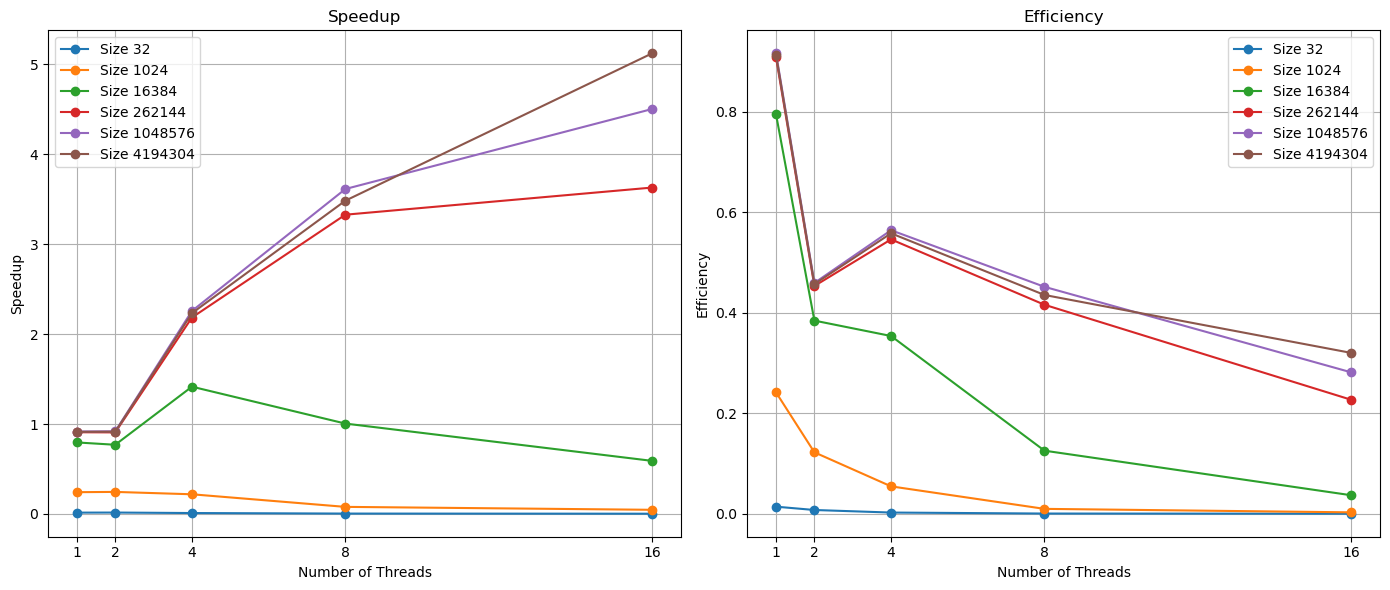

In [3]:
import re
import matplotlib.pyplot as plt
from collections import defaultdict

# File containing the timing output
filename = "output.txt"

# Dictionaries to hold parsed times
seq_times = {}                     # { size: sequential_time }
par_times = defaultdict(dict)      # { size: { threads: parallel_time } }

with open(filename, "r") as f:
    current_size = None
    current_threads = None

    for line in f:
        line = line.strip()

        # Parse sequential run lines
        if line.startswith("Running sequential FF with size"):
            # e.g. "Running sequential FF with size 16384"
            match = re.search(r"size (\d+)", line)
            if match:
                current_size = int(match.group(1))
                current_threads = 0  # use 0 or 1 as a placeholder for sequential
        elif line.startswith("# elapsed time") and current_threads == 0:
            # e.g. "# elapsed time (timer_seq_Tot): 0.00213633s"
            match = re.search(r": ([0-9.eE+-]+)s", line)
            if match and current_size is not None:
                seq_times[current_size] = float(match.group(1))
                current_size = None
                current_threads = None

        # Parse parallel run lines
        elif line.startswith("Running with") and "threads and size" in line:
            # e.g. "Running with 4 threads and size 262144"
            match = re.search(r"with (\d+) threads and size (\d+)", line)
            if match:
                current_threads = int(match.group(1))
                current_size = int(match.group(2))
        elif line.startswith("# elapsed time") and current_threads is not None:
            # e.g. "# elapsed time (timer_par_Tot): 0.0168147s"
            match = re.search(r": ([0-9.eE+-]+)s", line)
            if match and current_size is not None:
                par_times[current_size][current_threads] = float(match.group(1))
                current_size = None
                current_threads = None

# At this point:
#   - seq_times[size] = time of sequential run for that size
#   - par_times[size][threads] = time of parallel run for that size & thread-count

# Make sure we only consider sizes that appear in both seq_times and par_times
common_sizes = sorted(set(seq_times.keys()) & set(par_times.keys()))

# Get sorted list of thread counts
all_threads = sorted({t for size in par_times for t in par_times[size].keys()})

# Compute speedup and efficiency
speedup = defaultdict(list)      # { size: [S(1), S(2), ...] in order of all_threads }
efficiency = defaultdict(list)   # { size: [E(1), E(2), ...] in order of all_threads }

for size in common_sizes:
    T_seq = seq_times[size]
    for t in all_threads:
        # If for some (size, t) there is no measurement, skip or set None
        if t in par_times[size]:
            T_par = par_times[size][t]
            S = T_seq / T_par
            E = S / t
        else:
            S = None
            E = None

        speedup[size].append(S)
        efficiency[size].append(E)

print("Speedup and Efficiency Calculated:")
for size in common_sizes:
    print(f"Size {size}: Speedup = {speedup[size]}, Efficiency = {efficiency[size]}")   
# This script processes the output of a parallel program to calculate speedup and efficiency


# Plotting
plt.figure(figsize=(14, 6))

# 1) Speedup plot
plt.subplot(1, 2, 1)
for size in common_sizes:
    sp_vals = speedup[size]
    # Only plot where S is not None
    x = [all_threads[i] for i, s in enumerate(sp_vals) if s is not None]
    y = [s for s in sp_vals if s is not None]
    plt.plot(x, y, marker='o', label=f"Size {size}")
plt.title("Speedup")
plt.xlabel("Number of Threads")
plt.ylabel("Speedup")
plt.xticks(all_threads)
plt.legend()
plt.grid(True)

# 2) Efficiency plot
plt.subplot(1, 2, 2)
for size in common_sizes:
    eff_vals = efficiency[size]
    # Only plot where E is not None
    x = [all_threads[i] for i, e in enumerate(eff_vals) if e is not None]
    y = [e for e in eff_vals if e is not None]
    plt.plot(x, y, marker='o', label=f"Size {size}")
plt.title("Efficiency")
plt.xlabel("Number of Threads")
plt.ylabel("Efficiency")
plt.xticks(all_threads)
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.savefig("speedup_efficiency.png", dpi=300)  # <- Save figure

plt.show()


In [ ]:
# calcola la tabellina del numero inserito dall'utente

numero = int(input("dammi il numero di cui vuoi sapere la tabellina:"))
for i in range(1, 11, 1):
    print(numero * i)


password = "PASSWORDSEGRETA"
for i in range(1,4,1):
    tentativo = input(f"inserisci la password: tentativo numero {i}")
    if(tentativo == "PASSWORDSEGRETA"):
        print("Accesso garantito!")
    else:
        print(f"Accesso negato, password inserita = {password}")





4
8
12
16
20
24
28
32
36
40
Accesso negato, password inserita = PASSWORDSEGRETA
Accesso negato, password inserita = PASSWORDSEGRETA
Accesso garantito!


MPI STRONG/WEAK SCALABILITY

=== Strong Scalability ===
(size)   |  p=1    p=2    p=4    p=8    |  Eff@p=2   Eff@p=4   Eff@p=8
-----------------------------------------------------------------------
      32 |   1.00    0.23    0.25    0.25  |     0.113      0.061      0.031
    1024 |   1.00    0.24    0.25    0.23  |     0.118      0.061      0.029
   16384 |   1.00    0.24    0.22    0.26  |     0.119      0.055      0.033
  262144 |   1.00    0.39    0.56    0.51  |     0.196      0.140      0.063
 1048576 |   1.00    0.60    0.64    0.63  |     0.298      0.159      0.078
 4194304 |   1.00    0.82    0.75    0.73  |     0.410      0.187      0.092

=== Weak Scalability ===
 p  |  size    |   T(p) (s)   |  S_weak  |  E_weak
----------------------------------------------
 1  |  4194304 |     0.135764 |   1.000 |   1.000
 2  |  8388608 |     0.341659 |   0.397 |   0.199
 4  | 16777216 |     0.692128 |   0.196 |   0.049
 8  | 33554432 |     1.408420 |   0.096 |   0.012


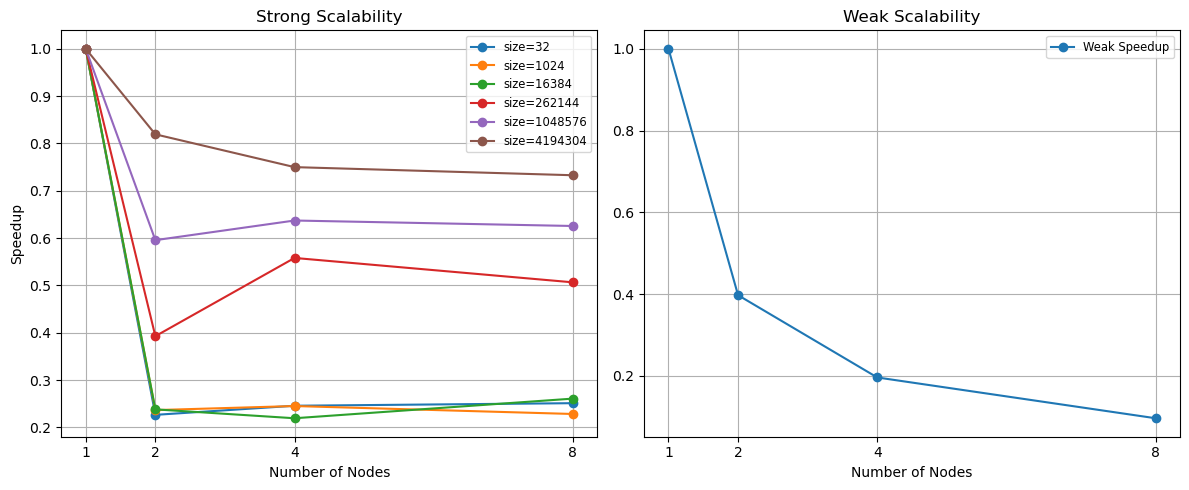

In [2]:
import re
import matplotlib.pyplot as plt
from collections import defaultdict

# -------------------------------
# 1) Parse "output.txt"
# -------------------------------

filename = "mpi_output.txt"

# data[size][nodes] = elapsed_time
data = defaultdict(dict)

with open(filename, "r") as f:
    current_nodes = None
    current_size = None

    for line in f:
        line = line.strip()

        # Match lines like:
        #   Running MPI test with 4 nodes and size 262144
        #   Running MPI test with 2 nodes and size 2**23
        m = re.match(r"Running MPI test with (\d+) nodes and size (.+)", line)
        if m:
            current_nodes = int(m.group(1))
            size_str = m.group(2)

            # If size is of the form "2**23", evaluate it
            if size_str.startswith("2**"):
                exponent = int(size_str.split("**")[1])
                current_size = 2 ** exponent
            else:
                current_size = int(size_str)

            continue

        # Once we see the elapsed‐time line, store it
        #   # elapsed time (timer_mpi_Tot): 0.0462825s
        if line.startswith("# elapsed time") and current_nodes is not None and current_size is not None:
            m2 = re.search(r": ([0-9.eE+-]+)s", line)
            if m2:
                t = float(m2.group(1))
                data[current_size][current_nodes] = t

            current_nodes = None
            current_size = None

# -------------------------------
# 2) Strong Scalability
# -------------------------------
#
# Strong scalability: for a fixed problem size, see how speedup behaves
# as we increase the number of nodes.
#
# For each "size" that has a 1-node run, and also runs at 2, 4, 8 nodes:
#    Speedup(size, p) = T(1, size) / T(p, size)
#    Efficiency(size, p) = Speedup(size, p) / p
#
# We'll gather all sizes for which (1, size) exists, then check p = 2, 4, 8.

# Find all sizes that have a 1-node measurement
sizes_with_1node = sorted(s for s, times in data.items() if 1 in times)

# We'll only consider sizes for which we also have times at 2, 4, and 8 nodes:
strong_sizes = []
for sz in sizes_with_1node:
    if all(p in data[sz] for p in (2, 4, 8)):
        strong_sizes.append(sz)

strong_sizes = sorted(strong_sizes)

# Compute speedup and efficiency for each strong_size
strong_speedup = defaultdict(dict)      # strong_speedup[size][p] = S
strong_efficiency = defaultdict(dict)   # strong_efficiency[size][p] = E

for sz in strong_sizes:
    T1 = data[sz][1]
    for p in (1, 2, 4, 8):
        Tp = data[sz].get(p)
        if Tp is not None:
            S = T1 / Tp
            E = S / p
            strong_speedup[sz][p] = S
            strong_efficiency[sz][p] = E

# -------------------------------
# 3) Weak Scalability
# -------------------------------
#
# Weak scalability: problem size scales with the number of nodes so that
# the work per node remains constant.  According to the problem statement:
#
#   - 1 node  → size = 2**22
#   - 2 nodes → size = 2**23
#   - 4 nodes → size = 2**24
#   - 8 nodes → size = 2**25
#
# We already parsed all those runs into `data`.  Let:
#   T1 = data[2**22][1]
#   T2 = data[2**23][2]
#   T4 = data[2**24][4]
#   T8 = data[2**25][8]
#
# Then define:
#   S_weak(p) = T1 / T(p)            (p ∈ {1,2,4,8})
#   E_weak(p) = S_weak(p) / p
#
# (Note: S_weak(1) = 1, E_weak(1) = 1.)

weak_mapping = {
    1: 2 ** 22,
    2: 2 ** 23,
    4: 2 ** 24,
    8: 2 ** 25,
}

# Check that all these entries exist
for p, sz in weak_mapping.items():
    if sz not in data or p not in data[sz]:
        raise RuntimeError(f"Missing data for weak‐scale: nodes={p}, size={sz}")

T1_weak = data[weak_mapping[1]][1]

weak_speedup = {}
weak_efficiency = {}

for p, sz in weak_mapping.items():
    Tp = data[sz][p]
    S_weak = T1_weak / Tp
    E_weak = S_weak / p
    weak_speedup[p] = S_weak
    weak_efficiency[p] = E_weak

# -------------------------------
# 4) Print Results
# -------------------------------

print("=== Strong Scalability ===")
print("(size)   |  p=1    p=2    p=4    p=8    |  Eff@p=2   Eff@p=4   Eff@p=8")
print("-----------------------------------------------------------------------")
for sz in strong_sizes:
    s1 = strong_speedup[sz][1]
    s2 = strong_speedup[sz][2]
    s4 = strong_speedup[sz][4]
    s8 = strong_speedup[sz][8]
    e2 = strong_efficiency[sz][2]
    e4 = strong_efficiency[sz][4]
    e8 = strong_efficiency[sz][8]
    print(f"{sz:8d} | {s1:6.2f}  {s2:6.2f}  {s4:6.2f}  {s8:6.2f}  |  {e2:8.3f}   {e4:8.3f}   {e8:8.3f}")

print("\n=== Weak Scalability ===")
print(" p  |  size    |   T(p) (s)   |  S_weak  |  E_weak")
print("----------------------------------------------")
for p in (1, 2, 4, 8):
    sz = weak_mapping[p]
    Tp = data[sz][p]
    Sw = weak_speedup[p]
    Ew = weak_efficiency[p]
    print(f"{p:2d}  | {sz:8d} | {Tp:12.6f} | {Sw:7.3f} | {Ew:7.3f}")

# -------------------------------
# 5) Optional: Plotting
# -------------------------------
#
# If you want to visualize:
#  - Strong scalability: plot Speedup vs. #nodes for each fixed size
#  - Weak scalability: plot S_weak vs. #nodes (and/or E_weak vs. #nodes)
#
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# 5a) Strong: Speedup curves
ax_s = axes[0]
for sz in strong_sizes:
    ps = [1, 2, 4, 8]
    Ss = [strong_speedup[sz][p] for p in ps]
    ax_s.plot(ps, Ss, marker='o', label=f"size={sz}")
ax_s.set_title("Strong Scalability")
ax_s.set_xlabel("Number of Nodes")
ax_s.set_ylabel("Speedup")
ax_s.set_xticks([1, 2, 4, 8])
ax_s.grid(True)
ax_s.legend(fontsize='small')

# 5b) Weak: Speedup & Efficiency
ax_w = axes[1]
ps_w = sorted(weak_mapping.keys())
Sw_vals = [weak_speedup[p] for p in ps_w]
Ew_vals = [weak_efficiency[p] for p in ps_w]

ax_w.plot(ps_w, Sw_vals, marker='o', label="Weak Speedup")
#ax_w.plot(ps_w, Ew_vals, marker='s', label="Weak Efficiency")
ax_w.set_title("Weak Scalability")
ax_w.set_xlabel("Number of Nodes")
ax_w.set_xticks(ps_w)
ax_w.grid(True)
ax_w.legend(fontsize='small')

plt.tight_layout()
plt.savefig("strong_weak_scalability.png", dpi=300)  # <- Save figure
plt.show()
